## Описание системы

В данной работе рассматривается модель колл-центра с одним оператором. Все входящие звонки поступают случайным образом, а время их обслуживания также является случайной величиной.

Система относится к типу M/M/1/0. Это означает, что:
- звонки поступают случайно с интенсивностью λ;
- время обслуживания имеет экспоненциальное распределение с параметром μ;
- в системе есть только один оператор;
- очередь отсутствует — если оператор занят, звонок теряется.

Таким образом, система моделирует ситуацию, когда клиент не ждёт в очереди, а просто не дозванивается, если линия занята.

В ходе моделирования анализируются следующие показатели:
- общее число поступивших звонков;
- число обслуженных звонков;
- число потерянных звонков;
- вероятность отказа;
- загрузка системы (доля времени, когда оператор занят).

## Алгоритм работы модели

Модель работает по принципу пошагового моделирования времени.

Сначала задаются начальные условия: текущее время, состояние оператора и счётчики звонков.

Далее последовательно генерируются моменты поступления звонков. Для каждого нового звонка проверяется состояние системы:

- если оператор свободен, звонок принимается в обслуживание, и генерируется время его обработки;
- если оператор занят, звонок не обслуживается и считается потерянным.

Этот процесс продолжается до тех пор, пока не будет достигнуто заданное время моделирования.

После завершения моделирования рассчитываются основные характеристики системы:
- вероятность отказа (доля потерянных звонков);
- коэффициент загрузки (сколько времени оператор был занят).

Таким образом, модель позволяет воспроизвести поведение системы во времени и оценить её эффективность.

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [112]:
def simulate_call_center(lmbda, mu, T=1000, seed=None):
    if seed is not None:
        np.random.seed(seed)
    t = 0.0
    t_free = 0.0
    total_calls = 0
    served_calls = 0
    lost_calls = 0
    busy_time = 0.0

    while t < T:
        interarrival_time = np.random.exponential(1 / lmbda)
        t += interarrival_time

        if t > T:
            break

        total_calls += 1
        if t >= t_free:
            served_calls += 1

            service_time = np.random.exponential(1 / mu)
            t_free = t + service_time
            busy_time += service_time
        else:
            lost_calls += 1

    refusal_probability = lost_calls / total_calls if total_calls > 0 else 0
    utilization = busy_time / T
    utilization = min(utilization, 1.0)

    return {
        "lambda": lmbda,
        "mu": mu,
        "T": T,
        "total_calls": total_calls,
        "served_calls": served_calls,
        "lost_calls": lost_calls,
        "refusal_probability": refusal_probability,
        "utilization_exp": utilization
    }

In [113]:
def run_multiple_experiments(lmbda, mu, T=1000, n_runs=30):
    refusal_probs = []
    utilizations = []
    total_requests_list = []
    served_requests_list = []
    lost_requests_list = []

    for seed in range(n_runs):
        result = simulate_call_center(lmbda, mu, T=T, seed=seed)
        refusal_probs.append(result["refusal_probability"])
        utilizations.append(result["utilization_exp"])
        total_requests_list.append(result["total_calls"])
        served_requests_list.append(result["served_calls"])
        lost_requests_list.append(result["lost_calls"])

    return {
        "λ": lmbda,
        "μ": mu,
        "Всего заявок (ср.)": np.mean(total_requests_list),
        "Обслужено (ср.)": np.mean(served_requests_list),
        "Потеряно (ср.)": np.mean(lost_requests_list),
        "P_отк (имитация, ср.)": np.mean(refusal_probs),
        "Загрузка (имитация, ср.)": np.mean(utilizations),
    }

In [114]:
def theoretical_mm10(lmbda, mu):
    refusal_probability = lmbda / (lmbda + mu)
    utilization = lmbda / (lmbda + mu)
    return refusal_probability, utilization

In [115]:
lmbda = 5
mu = 6
T = 1000

result = run_multiple_experiments(lmbda, mu, T)
p_ref_theory, util_theory = theoretical_mm10(lmbda, mu)

print("Результаты имитации:")
for key, value in result.items():
    print(f"{key}: {value}")

print("\nТеоретические значения:")
print(f"Вероятность отказа (теория): {p_ref_theory:.4f}")
print(f"Загрузка системы (теория): {util_theory:.4f}")

Результаты имитации:
λ: 5
μ: 6
Всего заявок (ср.): 4998.2
Обслужено (ср.): 2734.733333333333
Потеряно (ср.): 2263.4666666666667
P_отк (имитация, ср.): 0.45279861750949074
Загрузка (имитация, ср.): 0.4526664848401441

Теоретические значения:
Вероятность отказа (теория): 0.4545
Загрузка системы (теория): 0.4545


In [116]:
mu = 6
T = 1000
lambda_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

results = []

for lmbda in lambda_values:
    sim_result = run_multiple_experiments(lmbda, mu, T=T)
    p_ref_theory, util_theory = theoretical_mm10(lmbda, mu)
    sim_result["Вероятность отказа (теория)"] = p_ref_theory
    sim_result["Загрузка системы (теория)"] = util_theory
    results.append(sim_result)

df = pd.DataFrame(results)
df

,λ,μ,Всего заявок (ср.),Обслужено (ср.),Потеряно (ср.),"P_отк (имитация, ср.)","Загрузка (имитация, ср.)",Вероятность отказа (теория),Загрузка системы (теория)
0,1,6,995.400000,855.900000,139.500000,0.139965,0.142808,0.142857,0.142857
1,2,6,2013.000000,1507.600000,505.400000,0.251005,0.251872,0.250000,0.250000
2,3,6,3011.433333,2005.033333,1006.400000,0.334109,0.333143,0.333333,0.333333
3,4,6,4003.766667,2407.066667,1596.700000,0.398732,0.399274,0.400000,0.400000
4,5,6,4998.200000,2734.733333,2263.466667,0.452799,0.452666,0.454545,0.454545
5,6,6,5996.533333,3001.433333,2995.100000,0.499422,0.498269,0.500000,0.500000
6,7,6,7003.000000,3231.100000,3771.900000,0.538565,0.538162,0.538462,0.538462
7,8,6,7993.400000,3430.333333,4563.066667,0.570840,0.570517,0.571429,0.571429
8,9,6,8996.300000,3601.133333,5395.166667,0.599687,0.598505,0.600000,0.600000
9,10,6,9995.566667,3752.600000,6242.966667,0.624556,0.623832,0.625000,0.625000


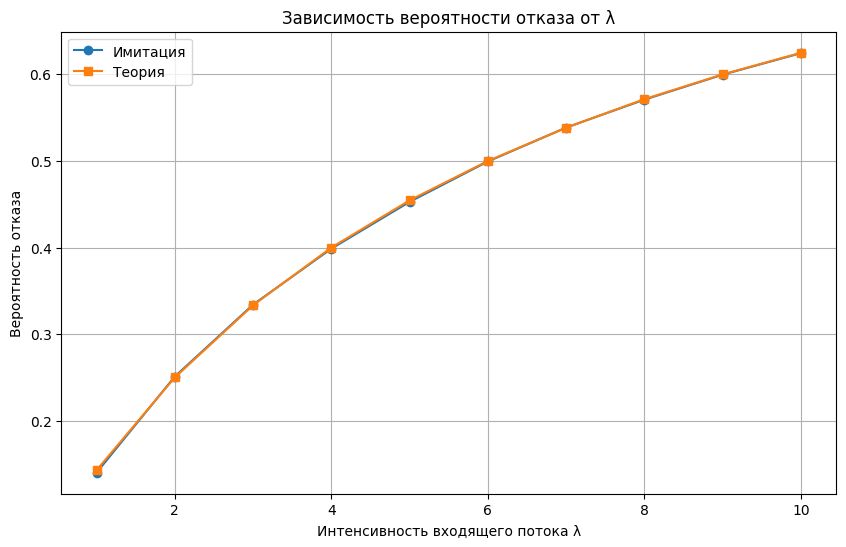

In [117]:
plt.figure(figsize=(10, 6))
plt.plot(df["λ"], df["P_отк (имитация, ср.)"], marker='o', label="Имитация")
plt.plot(df["λ"], df["Вероятность отказа (теория)"], marker='s', label="Теория")

plt.xlabel("Интенсивность входящего потока λ")
plt.ylabel("Вероятность отказа")
plt.title("Зависимость вероятности отказа от λ")
plt.grid(True)
plt.legend()
plt.show()

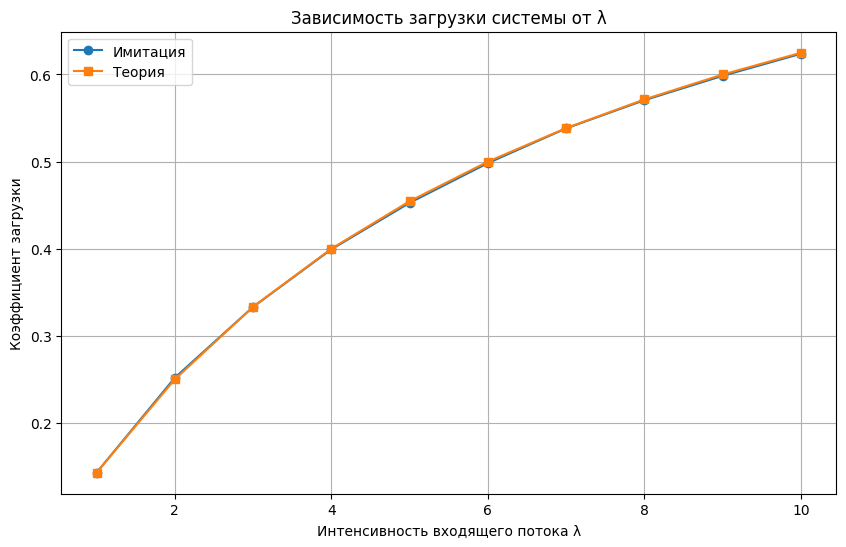

In [118]:
plt.figure(figsize=(10, 6))
plt.plot(df["λ"], df["Загрузка (имитация, ср.)"], marker='o', label="Имитация")
plt.plot(df["λ"], df["Загрузка системы (теория)"], marker='s', label="Теория")

plt.xlabel("Интенсивность входящего потока λ")
plt.ylabel("Коэффициент загрузки")
plt.title("Зависимость загрузки системы от λ")
plt.grid(True)
plt.legend()
plt.show()

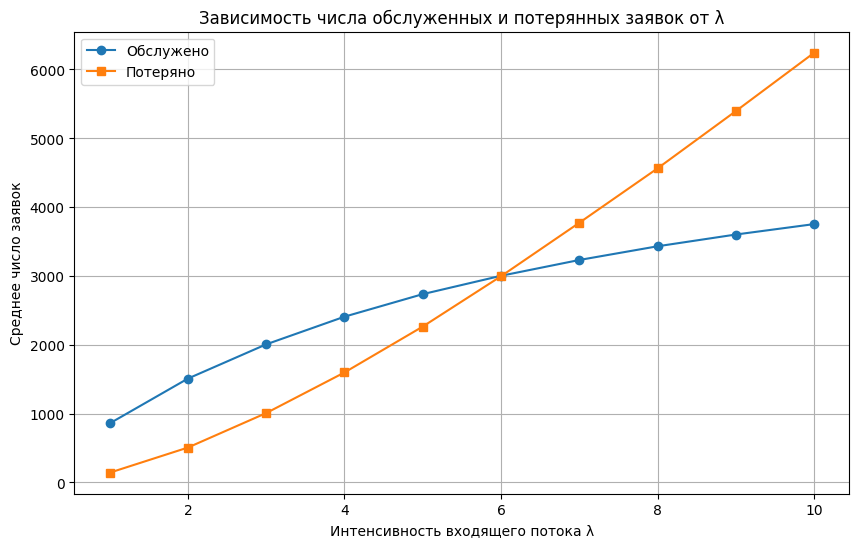

In [119]:
plt.figure(figsize=(10, 6))
plt.plot(df["λ"], df["Обслужено (ср.)"], marker='o', label="Обслужено")
plt.plot(df["λ"], df["Потеряно (ср.)"], marker='s', label="Потеряно")

plt.xlabel("Интенсивность входящего потока λ")
plt.ylabel("Среднее число заявок")
plt.title("Зависимость числа обслуженных и потерянных заявок от λ")
plt.grid(True)
plt.legend()
plt.show()

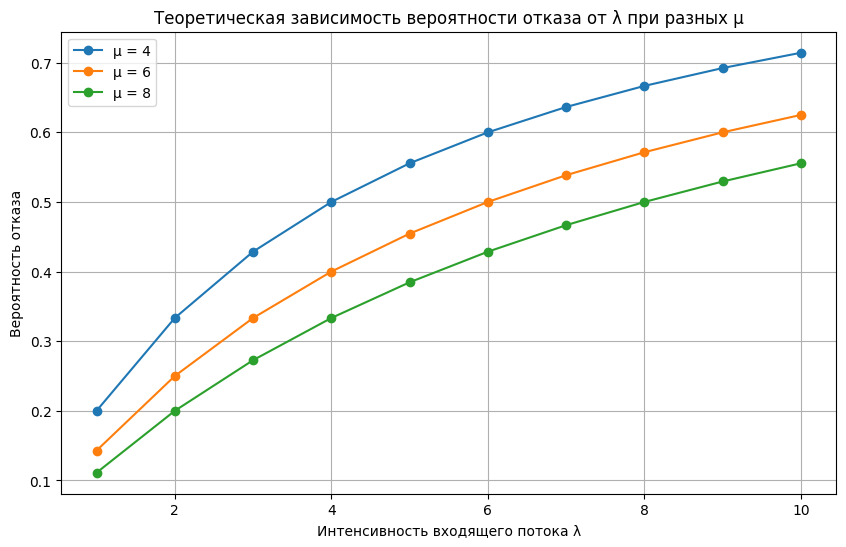

In [120]:
mu_values = [4, 6, 8]
lambda_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

plt.figure(figsize=(10, 6))

for mu in mu_values:
    probs = []
    for lmbda in lambda_values:
        p_ref_theory, _ = theoretical_mm10(lmbda, mu)
        probs.append(p_ref_theory)

    plt.plot(lambda_values, probs, marker='o', label=f"μ = {mu}")

plt.xlabel("Интенсивность входящего потока λ")
plt.ylabel("Вероятность отказа")
plt.title("Теоретическая зависимость вероятности отказа от λ при разных μ")
plt.grid(True)
plt.legend()
plt.show()

## Анализ результатов

В ходе экспериментов исследовалось, как изменяется поведение системы при увеличении интенсивности входящего потока λ, при фиксированном значении μ.

По результатам моделирования можно заметить, что при росте λ вероятность отказа увеличивается. Это логично, так как при большем числе входящих звонков оператор чаще оказывается занятым, и новые звонки не могут быть обслужены.

Аналогично растёт и загрузка системы - оператор всё больше времени находится в работе.

Сравнение с теоретическими значениями показало, что результаты имитации достаточно хорошо с ними совпадают. Небольшие отклонения объясняются тем, что моделирование основано на случайных величинах и ограничено по времени.

В целом полученные данные подтверждают ожидаемое поведение системы.

## Выводы

В рамках данной работы была построена имитационная модель колл-центра с одним оператором без очереди.

Эксперименты показали, что при увеличении интенсивности входящих звонков система начинает работать с перегрузкой: возрастает вероятность отказа, и всё больше клиентов не получают обслуживание.

Также было видно, что загрузка оператора увеличивается и при больших значениях λ приближается к максимальной.

Сравнение с теоретическими формулами показало хорошее совпадение результатов, что говорит о корректности модели.

Можно сделать вывод, что для уменьшения числа потерянных звонков необходимо либо снижать нагрузку на систему, либо увеличивать скорость обслуживания (или количество операторов).